<a href="https://colab.research.google.com/github/aadzy/ML-lab-2547201/blob/Lab-8/Tennis_Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ML Datasets/Lab 8/Lab 8 - Sheet1.csv')
display(df.head())

,No,Outlook,Temperature,Humidity,Wind,Play Tennis
0,1,Sunny,Hot,High,Weak,No
1,2,Sunny,Hot,High,Strong,No
2,3,Overcast,Hot,High,Weak,Yes
3,4,Rain,Mild,High,Weak,Yes
4,5,Rain,Cool,Normal,Weak,Yes


In [ ]:
df.shape

(50, 6)

In [ ]:
df.describe()

,No
count,50.00000
mean,25.50000
std,14.57738
min,1.00000
25%,13.25000
50%,25.50000
75%,37.75000
max,50.00000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   No           50 non-null     int64 
 1   Outlook      50 non-null     object
 2   Temperature  50 non-null     object
 3   Humidity     50 non-null     object
 4   Wind         50 non-null     object
 5   Play Tennis  50 non-null     object
dtypes: int64(1), object(5)
memory usage: 2.5+ KB



## 1.Data Preprocessing:



*   Splitting target and features from dataset
*   Label encoding categorical features (all features)


In [ ]:
from sklearn.preprocessing import LabelEncoder

X = df[['Outlook', 'Temperature', 'Humidity', 'Wind']].copy()  #Exclude "No" as a feature
y = df['Play Tennis'].copy()

# LabelEncoder to encode the categorical values
le = LabelEncoder()
for feature in X.columns:
    X[feature] = le.fit_transform(X[feature])
y = le.fit_transform(y)

print("Encoded Features (X) Head:")
display(pd.DataFrame(X).head(10))
print("\nEncoded Target (y) Head:")
display(pd.Series(y).head(10))

Encoded Features (X) Head:


,Outlook,Temperature,Humidity,Wind
0,2,1,0,1
1,2,1,0,0
2,0,1,0,1
3,1,2,0,1
4,1,0,1,1
5,1,0,1,0
6,0,0,1,0
7,2,2,0,1
8,2,0,1,1
9,1,2,1,1



Encoded Target (y) Head:


,0
0,0
1,0
2,1
3,1
4,1
5,0
6,1
7,0
8,1
9,1


## 2. Data Partitioning

* Split into Testing and Training data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (40, 4)
X_test shape: (10, 4)
y_train shape: (40,)
y_test shape: (10,)


## 3. Naive Bayes Model Training & Evaluation:


### Training model and predicting test data:

In [ ]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the Categorical Naive Bayes model
model = CategoricalNB()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)



###Evaluating the model:


In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
display(pd.DataFrame(conf_matrix, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

Accuracy: 0.8000

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.88      0.88      0.88         8

    accuracy                           0.80        10
   macro avg       0.69      0.69      0.69        10
weighted avg       0.80      0.80      0.80        10


Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,1,1
Actual 1,1,7


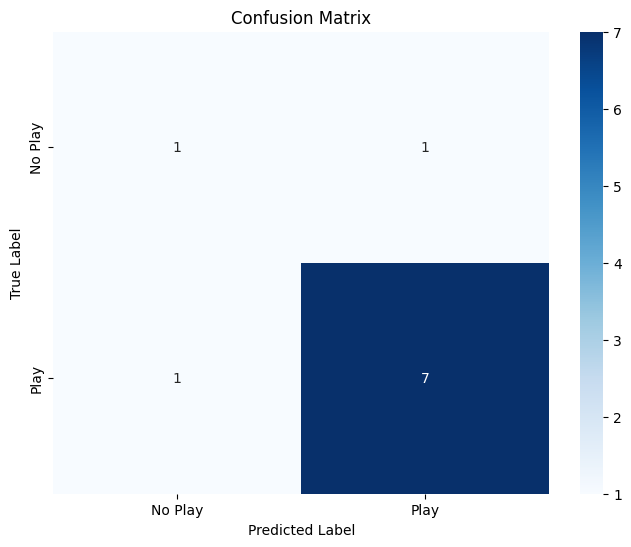

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Play', 'Play'], yticklabels=['No Play', 'Play'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## 4. Single-Sample Inference:

* Calculating outcome for given scenario:

In [ ]:
# Specific weather conditions for prediction
new_data = {
    'Outlook': 'Sunny',
    'Temperature': 'Cool',
    'Humidity': 'High',
    'Wind': 'Strong'
}

# Label encoding mappings (derived from previous LabelEncoder fits)
outlook_map = {'Overcast': 0, 'Rain': 1, 'Sunny': 2}
temperature_map = {'Cool': 0, 'Hot': 1, 'Mild': 2}
humidity_map = {'High': 0, 'Normal': 1}
wind_map = {'Strong': 0, 'Weak': 1}

# Encode the new specific weather conditions using the mappings
encoded_outlook = outlook_map[new_data['Outlook']] #2
encoded_temperature = temperature_map[new_data['Temperature']] #0
encoded_humidity = humidity_map[new_data['Humidity']] #0
encoded_wind = wind_map[new_data['Wind']] #0

# Create a DataFrame for prediction with feature names
new_input_df = pd.DataFrame(
    [[encoded_outlook, encoded_temperature, encoded_humidity, encoded_wind]],
    columns=['Outlook', 'Temperature', 'Humidity', 'Wind']
)

# Predict the class label
predicted_label_encoded = model.predict(new_input_df)[0]

# Define original class labels directly for decoding
original_class_labels = ['No', 'Yes']
predicted_label_decoded = original_class_labels[predicted_label_encoded]

# Predict the class probabilities
class_probabilities = model.predict_proba(new_input_df)[0]

# Display the results
print(f"Given conditions: {new_data}")
print(f"Encoded input for prediction: {new_input_df.iloc[0].values}")
print(f"\nPredicted class label: {predicted_label_decoded}")
print(f"Class probabilities: ")
for i, prob in enumerate(class_probabilities):
    print(f"  Probability of '{original_class_labels[i]}': {prob:.4f}")

Given conditions: {'Outlook': 'Sunny', 'Temperature': 'Cool', 'Humidity': 'High', 'Wind': 'Strong'}
Encoded input for prediction: [2 0 0 0]

Predicted class label: No
Class probabilities: 
  Probability of 'No': 0.9256
  Probability of 'Yes': 0.0744


## 5. Model Comparision

## 5. Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions on the test set
dt_y_pred = dt_model.predict(X_test)

# Evaluate the model
dt_accuracy = accuracy_score(y_test, dt_y_pred)
dt_report = classification_report(y_test, dt_y_pred)
dt_conf_matrix = confusion_matrix(y_test, dt_y_pred)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print("\nDecision Tree Classification Report:")
print(dt_report)
print("\nDecision Tree Confusion Matrix:")
display(pd.DataFrame(dt_conf_matrix, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Single-sample prediction for Decision Tree
dt_predicted_label_encoded = dt_model.predict(new_input_df)[0]
dt_predicted_label_decoded = original_class_labels[dt_predicted_label_encoded]

dt_class_probabilities = dt_model.predict_proba(new_input_df)[0]

print(f"\nDecision Tree Predicted class label for new sample: {dt_predicted_label_decoded}")
print("Decision Tree Class probabilities for new sample: ")
for i, prob in enumerate(dt_class_probabilities):
    print(f"  Probability of '{original_class_labels[i]}': {prob:.4f}")

Decision Tree Accuracy: 0.8000

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.88      0.88      0.88         8

    accuracy                           0.80        10
   macro avg       0.69      0.69      0.69        10
weighted avg       0.80      0.80      0.80        10


Decision Tree Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,1,1
Actual 1,1,7



Decision Tree Predicted class label for new sample: No
Decision Tree Class probabilities for new sample: 
  Probability of 'No': 1.0000
  Probability of 'Yes': 0.0000


## 6. Logistic Regression Classifier

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression Classifier
# Setting solver to 'liblinear' for small datasets or 'lbfgs' is a common choice.
# max_iter is increased to ensure convergence.
lr_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions on the test set
lr_y_pred = lr_model.predict(X_test)

# Evaluate the model
lr_accuracy = accuracy_score(y_test, lr_y_pred)
lr_report = classification_report(y_test, lr_y_pred)
lr_conf_matrix = confusion_matrix(y_test, lr_y_pred)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print("\nLogistic Regression Classification Report:")
print(lr_report)
print("\nLogistic Regression Confusion Matrix:")
display(pd.DataFrame(lr_conf_matrix, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Single-sample prediction for Logistic Regression
lr_predicted_label_encoded = lr_model.predict(new_input_df)[0]
lr_predicted_label_decoded = original_class_labels[lr_predicted_label_encoded]

lr_class_probabilities = lr_model.predict_proba(new_input_df)[0]

print(f"\nLogistic Regression Predicted class label for new sample: {lr_predicted_label_decoded}")
print("Logistic Regression Class probabilities for new sample: ")
for i, prob in enumerate(lr_class_probabilities):
    print(f"  Probability of '{original_class_labels[i]}': {prob:.4f}")

Logistic Regression Accuracy: 0.4000

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.67      0.50      0.57         8

    accuracy                           0.40        10
   macro avg       0.33      0.25      0.29        10
weighted avg       0.53      0.40      0.46        10


Logistic Regression Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,0,2
Actual 1,4,4



Logistic Regression Predicted class label for new sample: No
Logistic Regression Class probabilities for new sample: 
  Probability of 'No': 0.9466
  Probability of 'Yes': 0.0534


###  Support Vector Machine (SVM) Classifier

In [ ]:
from sklearn.svm import SVC

# Initialize the SVM Classifier
# Set probability=True to enable predict_proba for class probabilities
svm_model = SVC(random_state=42, probability=True)

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions on the test set
svm_y_pred = svm_model.predict(X_test)

# Evaluate the model
svm_accuracy = accuracy_score(y_test, svm_y_pred)
svm_report = classification_report(y_test, svm_y_pred)
svm_conf_matrix = confusion_matrix(y_test, svm_y_pred)

print(f"SVM Accuracy: {svm_accuracy:.4f}")
print("\nSVM Classification Report:")
print(svm_report)
print("\nSVM Confusion Matrix:")
display(pd.DataFrame(svm_conf_matrix, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Single-sample prediction for SVM
svm_predicted_label_encoded = svm_model.predict(new_input_df)[0]
svm_predicted_label_decoded = original_class_labels[svm_predicted_label_encoded]

svm_class_probabilities = svm_model.predict_proba(new_input_df)[0]

print(f"\nSVM Predicted class label for new sample: {svm_predicted_label_decoded}")
print("SVM Class probabilities for new sample: ")
for i, prob in enumerate(svm_class_probabilities):
    print(f"  Probability of '{original_class_labels[i]}': {prob:.4f}")

SVM Accuracy: 0.7000

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.78      0.88      0.82         8

    accuracy                           0.70        10
   macro avg       0.39      0.44      0.41        10
weighted avg       0.62      0.70      0.66        10


SVM Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,0,2
Actual 1,1,7



SVM Predicted class label for new sample: No
SVM Class probabilities for new sample: 
  Probability of 'No': 0.9751
  Probability of 'Yes': 0.0249


### Model Comparison Summary Table

In [36]:
model_names = ['Categorical Naive Bayes', 'Decision Tree', 'Logistic Regression', 'SVM']
accuracies = [accuracy, dt_accuracy, lr_accuracy, svm_accuracy]
predicted_labels = [predicted_label_decoded, dt_predicted_label_decoded, lr_predicted_label_decoded, svm_predicted_label_decoded]

# Prepare class probabilities as formatted strings
nb_prob_str = f"No: {class_probabilities[0]:.4f}, Yes: {class_probabilities[1]:.4f}"
dt_prob_str = f"No: {dt_class_probabilities[0]:.4f}, Yes: {dt_class_probabilities[1]:.4f}"
lr_prob_str = f"No: {lr_class_probabilities[0]:.4f}, Yes: {lr_class_probabilities[1]:.4f}"
svm_prob_str = f"No: {svm_class_probabilities[0]:.4f}, Yes: {svm_class_probabilities[1]:.4f}"
class_probs_str = [nb_prob_str, dt_prob_str, lr_prob_str, svm_prob_str]

summary_data = {
    'Model': model_names,
    'Test Accuracy': [f"{acc:.2%}" for acc in accuracies],
    'Single-Sample Prediction': predicted_labels,
    'Single-Sample Probabilities': class_probs_str
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

,Model,Test Accuracy,Single-Sample Prediction,Single-Sample Probabilities
0,Categorical Naive Bayes,80.00%,No,"No: 0.9256, Yes: 0.0744"
1,Decision Tree,80.00%,No,"No: 1.0000, Yes: 0.0000"
2,Logistic Regression,40.00%,No,"No: 0.9466, Yes: 0.0534"
3,SVM,70.00%,No,"No: 0.9751, Yes: 0.0249"


### Confusion Matrix Comparison

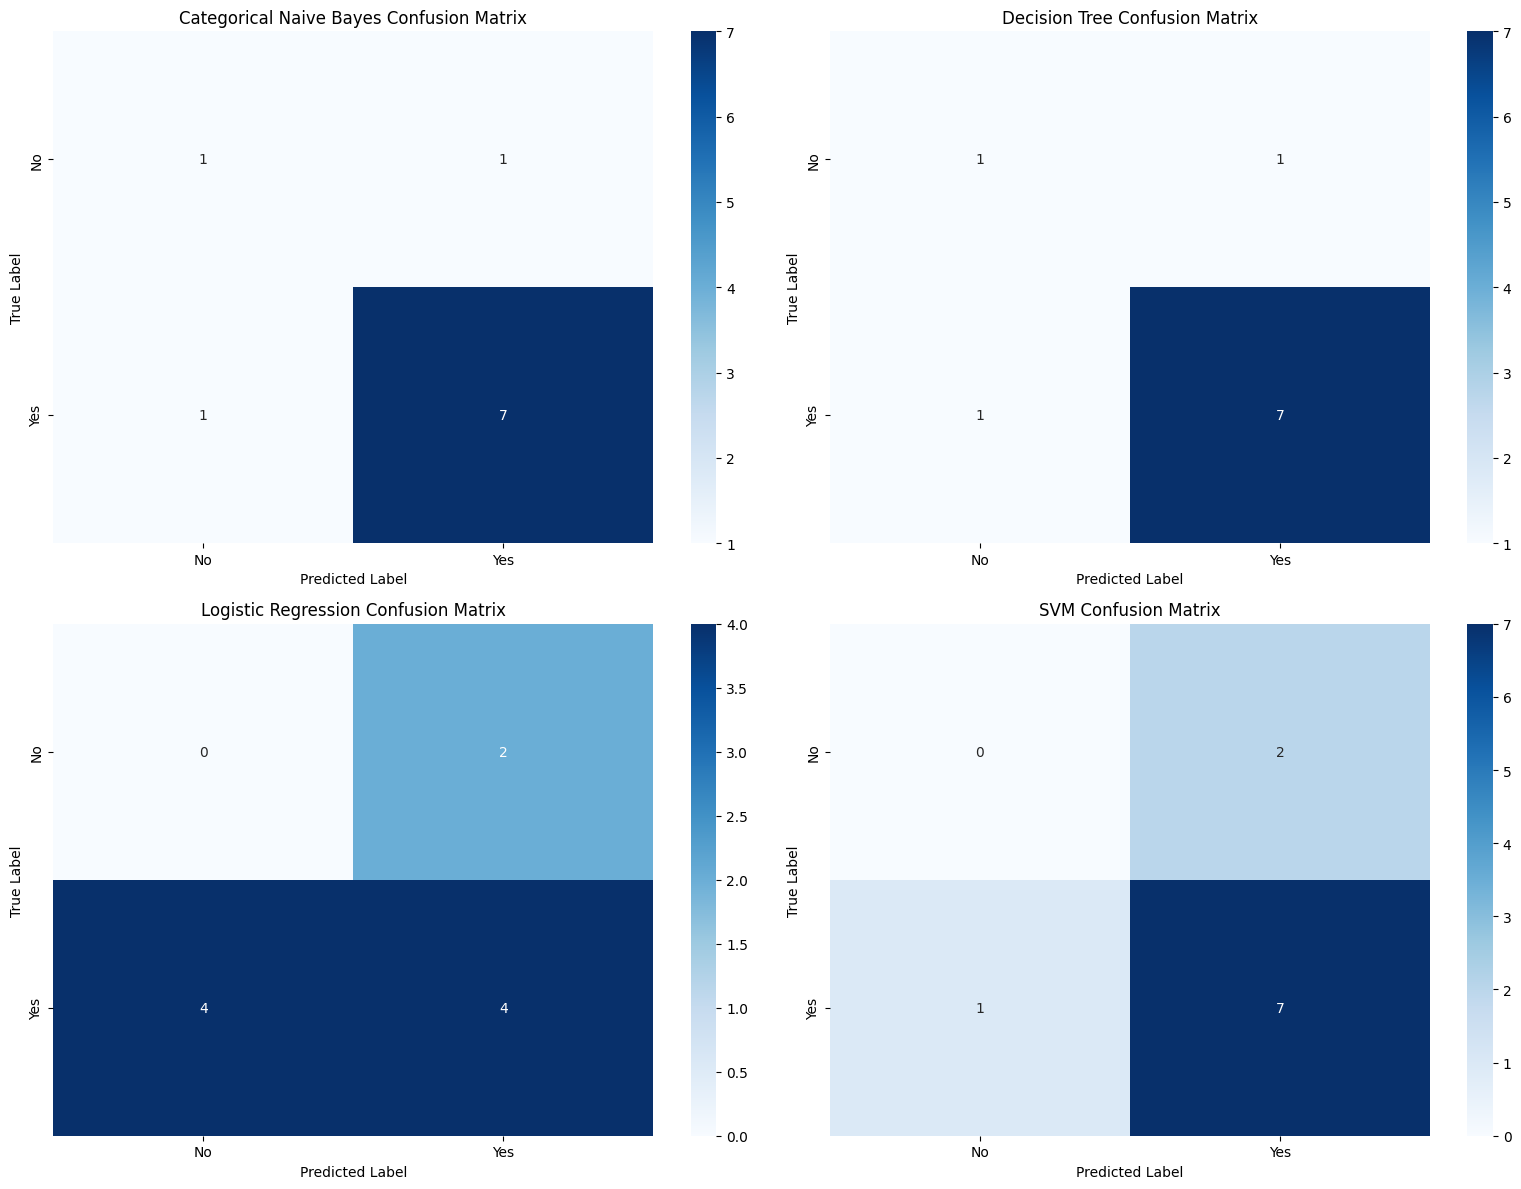

In [37]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # 2 rows, 2 columns
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

confusion_matrices = [
    (conf_matrix, 'Categorical Naive Bayes'),
    (dt_conf_matrix, 'Decision Tree'),
    (lr_conf_matrix, 'Logistic Regression'),
    (svm_conf_matrix, 'SVM')
]

for i, (cm, title) in enumerate(confusion_matrices):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=original_class_labels,
        yticklabels=original_class_labels,
        ax=axes[i]
    )
    axes[i].set_title(f'{title} Confusion Matrix')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()